In [1]:
# ── GLOBAL CONFIG ─────────────────────────────────────────────────────────
USE_MOCK = True   # Set False to use real OpenAI client

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║   demo_automated_pipeline.ipynb  —  4-Agent AML Escalation System        ║
# ║   Triage → Risk Analyst → Structuring Expert → Compliance Officer        ║
# ║                                                                          ║
# ║   All outputs → starter/outputs/                                         ║
# ║   Dashboard   → cd starter && streamlit run app.py                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# 4-Agent AML Escalation System

## System Overview
The `demo_automated_pipeline.ipynb` orchestrates a sophisticated multi-agent investigation workflow designed for regulatory AML compliance.

### Workflow Pipeline
Triage ➔ Risk Analyst ➔ Structuring Expert ➔ Compliance Officer

---

### Project Directories
* **Outputs:** `starter/outputs/` 
  * *Contains all generated investigation artifacts and SAR documents.*

### Launching the Dashboard
To visualize the agent decision outputs, navigate to the project root and execute:

```bash
`cd starter && streamlit run app.py`

In [3]:
import subprocess, sys
print("*"*80)
print("✅ Installing Dependencies")
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade" ,"-r", "../requirements.txt", "-q"], check=True)
print("*"*80)
print("\n\n")
print("*"*80)
print("✅ Dependencies are updated and ready to use")
print("*"*80)

********************************************************************************
✅ Installing Dependencies



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


********************************************************************************



********************************************************************************
✅ Dependencies are updated and ready to use
********************************************************************************


In [4]:
# ── CELL 1 — Environment Setup ────────────────────────────────────────────
import os
import sys
import json
import uuid
import pandas as pd
from datetime import datetime
from dotenv import load_dotenv
 
# Add starter/src/ to path (notebook lives in starter/notebooks/)
sys.path.append(os.path.abspath('../src'))
load_dotenv('../.env')
 
from foundation_sar import DataLoader, ExplainabilityLogger, load_csv_data
 
print("📚 Libraries imported successfully!")
print("🔐 Environment variables loaded")
print("📂 Source directory added to Python path")
 

📚 Libraries imported successfully!
🔐 Environment variables loaded
📂 Source directory added to Python path


In [5]:
# ── CELL 2 — OpenAI Client ───────────────────────────────────────────────
import openai
 
openai_api_key = os.getenv('OPENAI_API_KEY')
 
if not openai_api_key:
    print("⚠️  WARNING: No OpenAI API key found — running in MOCK mode")
    client = None
else:
    client = openai.OpenAI(
        base_url="https://openai.vocareum.com/v1",
        api_key=openai_api_key,
    )
    print("✅ OpenAI client initialized with Vocareum routing")
    print(f"🔑 API key : {openai_api_key[:8]}...{openai_api_key[-4:]}")
    print("📍 Base URL: https://openai.vocareum.com/v1")
 

✅ OpenAI client initialized with Vocareum routing
🔑 API key : your_ope...here
📍 Base URL: https://openai.vocareum.com/v1


In [6]:
# ── CELL 3 — Logger + Model Tier Selection ───────────────────────────────
from IPython.display import clear_output, display
from config_manager import get_model_input
 
logger                = ExplainabilityLogger()
explainability_logger = ExplainabilityLogger("../outputs/audit_logs/demo_pipeline.jsonl")
 
clear_output()
selector, ui_display = get_model_input()
display(ui_display)

Output()

In [7]:
# ── CELL 4 — Agent & Orchestrator Init ───────────────────────────────────
from src.mock.mock_client import InternalMockClient
from structuring_expert import StructuringExpert
from triage_analyst_agent import TriageAgent
from risk_analyst_agent import RiskAnalystAgent
from compliance_officer_agent import ComplianceOfficerAgent
from src.orchestrator import FraudOrchestrator

if USE_MOCK:
    active_client = InternalMockClient()
    print("🧪 Running in MOCK mode")
else:
    if client is None:
        raise ValueError("❌ USE_MOCK is False but no OpenAI client found — check your API key in .env")
    active_client = client
    print("🌐 Running with real OpenAI client")

triage_agent     = TriageAgent(active_client, logger)
risk_agent       = RiskAnalystAgent(active_client, logger)
expert_agent     = StructuringExpert(active_client, logger)
compliance_agent = ComplianceOfficerAgent(active_client, logger)

orchestrator = FraudOrchestrator(
    logger       = logger,
    client       = active_client,
    use_mock     = USE_MOCK,
    triage       = triage_agent,
    risk_analyst = risk_agent,
    expert       = expert_agent,
    officer      = compliance_agent,
)

print("✅ Agents and Orchestrator initialized")
print(f"   USE_MOCK        : {USE_MOCK}")
print(f"   Client ID       : {id(active_client)}")
print(f"   Orchestrator ID : {id(orchestrator.client)}")
print(f"   Triage Agent ID : {id(triage_agent.client)}")

🧪 Running in MOCK mode
DEBUG [TriageAgent]: Received client ID 137199874551696
DEBUG [RiskAnalystAgent]: Received client ID 137199874551696
DEBUG [StructuringExpert]: Received client ID 137199874551696
DEBUG [ComplianceOfficerAgent]: Received client ID 137199874551696
DEBUG [Orchestrator]: Received client ID 137199874551696
DEBUG [Orchestrator]: Assigned self.client ID 137199874551696
✅ Agents and Orchestrator initialized
   USE_MOCK        : True
   Client ID       : 137199874551696
   Orchestrator ID : 137199874551696
   Triage Agent ID : 137199874551696


In [8]:
# ── CELL 5 — Data Loading ────────────────────────────────────────────────
from demo_integration_pipeline import load_and_preprocess_data
 
notebook_dir = os.getcwd()
data_dir     = os.path.abspath(os.path.join(notebook_dir, '..', 'data'))
print(f"📂 Loading data from: {data_dir}")
 
customers_data, accounts_data, transactions_data = load_and_preprocess_data(data_dir)
 

📂 Loading data from: /workspace/cd14685-fin-serv-agentic-c1-classroom/project/starter/data
📊 Loading Cleaned Financial Data
🧹 Stage 2: Cleaning missing values...
✅ Data cleaned.
🔄 Stage 3: Converting to dictionary format...
✅ Conversion complete.
📈 Loaded: 150 customers, 178 accounts, 4268 transactions


In [9]:
# ── CELL 6 — Customer Risk Screening ─────────────────────────────────────
from demo_integration_pipeline import screen_high_risk_customers
 
selected_customers, rest_of_cases = screen_high_risk_customers(
    customers_data, accounts_data, transactions_data
)
 
print(f"\n📊 Top high-risk cases : {len(selected_customers)}")
print(f"   Remaining cases     : {len(rest_of_cases)}")

🔍 Customer Risk Screening
🔍 Screening 150 customers for high-risk flags...
📊 Selected 9 top-risk customers
   Remaining flagged : 16

📊 Top high-risk cases : 9
   Remaining cases     : 16


In [10]:
# ── CELL 7 — Build CaseData Objects ──────────────────────────────────────
from demo_integration_pipeline import build_case_objects
 
data_loader     = DataLoader(explainability_logger)
 
high_risk_cases = build_case_objects(selected_customers, data_loader)
remaining_cases = build_case_objects(rest_of_cases,      data_loader)
 
print(f"\n✅ high_risk_cases : {len(high_risk_cases)}")
print(f"   remaining_cases  : {len(remaining_cases)}")

✅ Built 9 CaseData objects.
✅ Built 16 CaseData objects.

✅ high_risk_cases : 9
   remaining_cases  : 16


In [11]:
# ── CELL 8 — Run 4-Agent Pipeline ────────────────────────────────────────
from demo_integration_pipeline import run_agent_pipeline
 
# HIGH RISK batch
res1 = run_agent_pipeline(high_risk_cases, orchestrator, is_high_risk=True)
processed_cases_hr, approved_sars_hr, rejected_cases_hr, audit_decisions_hr, label_hr = res1
 
# REMAINING batch
res2 = run_agent_pipeline(remaining_cases, orchestrator, is_high_risk=False)
processed_cases_rm, approved_sars_rm, rejected_cases_rm, audit_decisions_rm, label_rm = res2
 
# Merge into a single set of tracking variables used by metrics + exports
processed_cases = processed_cases_hr + processed_cases_rm
approved_sars   = approved_sars_hr   + approved_sars_rm
rejected_cases  = rejected_cases_hr  + rejected_cases_rm
audit_decisions = audit_decisions_hr + audit_decisions_rm
 
print(f"\n📊 Combined totals — Processed: {len(processed_cases)} | "
      f"Approved: {len(approved_sars)} | Rejected: {len(rejected_cases)}")
 


  🚀 4-AGENT ESCALATION PIPELINE — HIGH RISK CASES

🔍 Case: 40022acd-56d0-4fdc-a76d-e811278aff9e | Customer: Jacqueline Rodriguez
DEBUG [Triage]: status=COMPLETE
DEBUG [Expert]: status=COMPLETE
DEBUG [Compliance] keys received: ['case_id', 'customer', 'accounts', 'transactions', 'case_created_at', 'data_sources', 'risk_rating', '_customer_name', 'status', 'is_suspicious', 'primary_risk_category', 'thought_process', 'triage_summary', 'confidence_score', 'feedback_addressed', 'analysis_depth', 'pattern_found', 'layering_indicators', 'reasoning', 'recommended_sar_priority']
DEBUG [Compliance]: status=COMPLETE
✅ SAR saved: /workspace/cd14685-fin-serv-agentic-c1-classroom/project/starter/outputs/filed_sars/SAR_1914d15e.json
✅ SAR successfully saved: /workspace/cd14685-fin-serv-agentic-c1-classroom/project/starter/outputs/filed_sars/SAR_1914d15e.json
   ✅ AI-ONLY SAR filed | Structuring | 91% confidence

🔍 Case: ca9f35d6-d1f3-471c-9fba-40e66edc02ae | Customer: Michael Stanley
DEBUG [Triage]:

In [12]:
# ── CELL 9 — Workflow Metrics ─────────────────────────────────────────────
from demo_integration_pipeline import analyze_workflow_efficiency, validate_ai_decisions
 
analyze_workflow_efficiency(processed_cases, approved_sars, rejected_cases, audit_decisions)
validate_ai_decisions(audit_decisions)


      CORPORATE SAR WORKFLOW DASHBOARD
Throughput Metrics:
  Total Volume         : 25 cases
  SAR Filing Volume    : 7
  Cases Filtered Early : 18

Time Efficiency (vs Human Baseline ~30min/case):
  Avg AI Processing    : 0.13s per case
  Time Saved           : ~100.0% faster than manual review
  Approx Throughput    : 475.4 cases per minute

Financial Performance (vs Full Human Workflow):
  AI Pipeline Cost     : $47.50
  Human Equivalent     : $3175.00
  Cost Savings         : $3127.50
  ROI                  : 98.5% cost reduction

Operational KPIs:
  High Confidence Rate : 24.0% of cases >= 80% confidence
  Triage Filter Rate   : 72.0%

-------     AI Decision Analytics     -------
Average AI Model Confidence : 81.12%
Confidence (Median)         : 78.00%
Manual Human Overrides      : 18 cases
---------------------------------------------

Cases rejected by human reviewer:
  - Case ID: ca9f35d6-d1f3-471c-9fba-40e66edc02ae (Michael Stanley)
  - Case ID: cb965030-824a-4a50-9cfb-2b1fb

In [13]:
# ── CELL 10 — Batch Visualisation ────────────────────────────────────────
import yaml
from IPython.display import Image
from demo_integration_pipeline import WorkflowVisualizer
 
with open('../config/pipeline_config.yaml', 'r') as f:
    config = yaml.safe_load(f)
 
OUTPUT_DIR    = config['directories']['output_charts']
REVIEW_ALL    = False   # Set True to chart remaining_cases separately too
 
batches = [("Selected_Customers", selected_customers)]
if REVIEW_ALL:
    batches.append(("Remaining_Customers", rest_of_cases))
    print("🚀 Full-scale review mode: Enabled")
else:
    print("🛡️  Managed review mode: Top-N high-risk cases only")
 
reporter = WorkflowVisualizer(output_dir=OUTPUT_DIR)
 
for i, (name, customer_group) in enumerate(batches, start=1):
    print(f"\n--- Chart batch: {name} ({len(customer_group)} cases) ---")
    reporter.generate(approved_sars, rejected_cases, audit_decisions, batch_num=i)
 

🛡️  Managed review mode: Top-N high-risk cases only

--- Chart batch: Selected_Customers (9 cases) ---
✅ Charts saved to ../outputs/charts  [520918_*_batch1.png]



--- 📊 Final Dashboard ---

✨ Results for: BATCH1


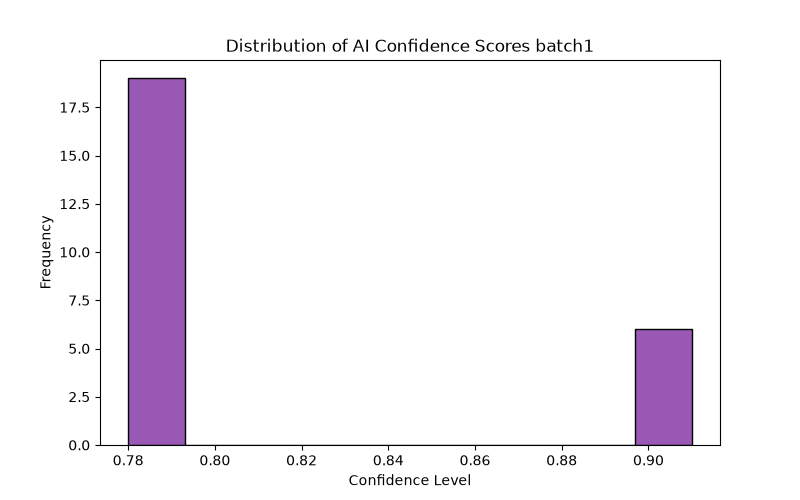

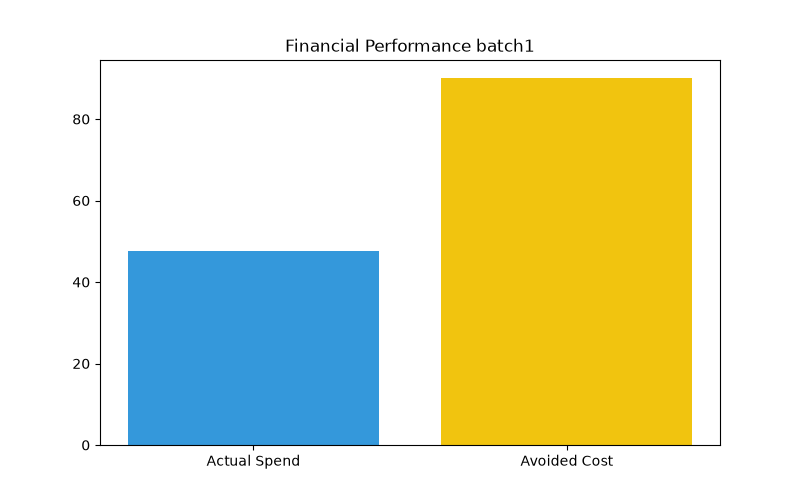

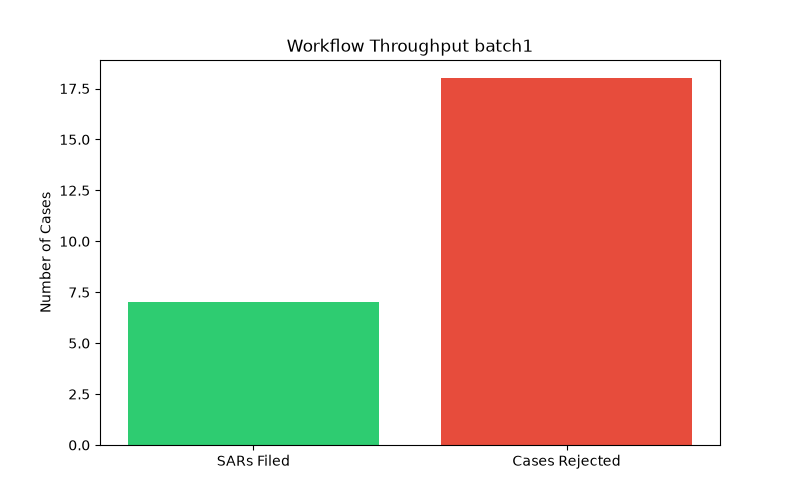

In [14]:
# ── CELL 11 — Display Charts ──────────────────────────────────────────────
print("\n--- 📊 Final Dashboard ---")
 
current_run_files = sorted([
    f for f in os.listdir(OUTPUT_DIR)
    if f.startswith(reporter.timestamp)
])
 
batches_run = sorted(set(
    f.split('_')[-1].replace('.png', '') for f in current_run_files
))
 
for batch in batches_run:
    print(f"\n✨ Results for: {batch.upper()}")
    for file in sorted(f for f in current_run_files if batch in f):
        display(Image(filename=os.path.join(OUTPUT_DIR, file)))
 

In [15]:
# ── CELL 12 — Dashboard Data Sync (payload by batch) ─────────────────────
from demo_integration_pipeline import sync_dashboard_data
 
payload = {
    label_hr: {
        "processed":      processed_cases_hr,
        "approved":       approved_sars_hr,
        "rejected":       rejected_cases_hr,
        "audit_decisions": audit_decisions_hr,
    },
    label_rm: {
        "processed":      processed_cases_rm,
        "approved":       approved_sars_rm,
        "rejected":       rejected_cases_rm,
        "audit_decisions": audit_decisions_rm,
    },
}
 
sync_dashboard_data(payload)
 
# Debug: confirm audit_decisions columns are complete
import pandas as pd
test_df = pd.DataFrame(audit_decisions_hr)
print("\nAudit decision columns:", test_df.columns.tolist())

✅ Data synced → /workspace/cd14685-fin-serv-agentic-c1-classroom/project/starter/outputs/live_dashboard/dashboard_data_sample.json

Audit decision columns: ['case_id', 'customer_id', 'customer_name', 'risk_rating', 'decision', 'ai_classification', 'ai_confidence', 'compliance_narrative_exists', 'processing_time_seconds']


In [16]:
# ── CELL 13 — Aggregate SAR History → Parquet ────────────────────────────
# Writes to: starter/outputs/live_dashboard/sar_history.parquet
#        and: starter/outputs/live_dashboard/sar_history_meta.json
from demo_integration_pipeline import aggregate_sar_history
 
df_history = aggregate_sar_history(config)
 
 
# ── CELL 14 — Build Enriched Case Records & Export Live Session ───────────
# Writes to: starter/outputs/live_dashboard/live_session.json
from demo_integration_pipeline import build_all_case_records, export_live_session
 
all_cases = build_all_case_records(
    selected_customers,
    rest_of_cases,
    audit_decisions,
    approved_sars,
    rejected_cases,
)
 
export_live_session(all_cases, approved_sars, rejected_cases)

Loaded 21 / 21 files.  Failures: 0

--- classification value_counts ---
classification
Structuring    18
Other           3
Name: count, dtype: int64

--- risk_level value_counts ---
risk_level
Medium    12
High       9
Name: count, dtype: int64

--- review_status value_counts ---
review_status
ai_only           18
human_approved     3
Name: count, dtype: int64

--- compliance_status value_counts ---
compliance_status
approved    21
Name: count, dtype: int64

--- risk_rating value_counts ---
risk_rating
Medium    12
High       9
Name: count, dtype: int64

--- human_reviewer value_counts ---
human_reviewer
NaN                   18
compliance_officer     3
Name: count, dtype: int64

--- ai_generated value_counts ---
ai_generated
True    21
Name: count, dtype: int64

--- ai_agents_used (exploded) ---
ai_agents_used
RiskAnalyst          21
ComplianceOfficer    21
Name: count, dtype: int64

filing_date range  : 2026-06-18T16:38:18.229827 → 2026-06-18T18:09:51.275870
duplicate sar_id   : 0
du

In [17]:
import pandas as pd
df = pd.read_csv("../outputs/live_dashboard/sar_history.csv")
print(df["review_status"].value_counts())
print(df[["sar_id", "case_id", "review_status"]])

review_status
ai_only           18
human_approved     3
Name: count, dtype: int64
          sar_id                               case_id   review_status
0   SAR_0ec637c2  a8b68534-1b1b-482a-a503-fdcb207766f7  human_approved
1   SAR_1914d15e  40022acd-56d0-4fdc-a76d-e811278aff9e         ai_only
2   SAR_19888a63  fe736640-b280-4cac-a37e-12857955b9d2         ai_only
3   SAR_1b33889f  625f6eed-ce0f-4789-b6c4-78568a0b0d7b         ai_only
4   SAR_2492f385  67d38acd-1ad7-4546-a1cc-b371851c8260  human_approved
5   SAR_283454df  ad99ac19-56ca-4d1d-af4f-a6cb31d6eb3e         ai_only
6   SAR_32a5a123  e5263686-73d3-436f-a46a-d16bf2d4f439         ai_only
7   SAR_3c2dd3c8  b9b5f492-3f87-443d-b69f-f548b91ba279         ai_only
8   SAR_442352c7  e876a8c4-fbd1-4b1b-8049-051626615e54         ai_only
9   SAR_50f2917c  cb8909fb-360c-4a9a-882a-9db322d901ed         ai_only
10  SAR_5353a454  1ee957bc-9518-4bde-ac59-a62d91d1bd46         ai_only
11  SAR_6e580028  7a75f633-7b93-40f6-95c3-4ed12998ddbd         ai_